# 10 - Presentation Tables

### Notebook Overview

Render the three results tables used in the presentation with a consistent blue-red palette that matches the correlation heatmap from `03-eda.ipynb`.

**Inputs:**
- `../data/manual-test-results.csv`
- `../pycaret/pycaret-raw-test-results.csv`
- `../pycaret/pycaret-preprocessed-test-results.csv`

**Outputs:**
- `../visualizations/results-manual.png`
- `../visualizations/results-pycaret-raw.png`
- `../visualizations/results-pycaret-preprocessed.png`

**Palette:** `RdBu_r` on MAE/RMSE (blue = low = good) and `RdBu` on R² (blue = high = good), so "good = cool, bad = warm" reads consistently across all three metrics.

### 1 - Setup

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualisations
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm

### 2 - Table Renderer

A single reusable function: takes a dataframe with `Model`, `MAE`, `RMSE`, `R2` columns and writes a styled PNG. Each numeric column gets coloured by its own gradient so relative comparisons within a column read cleanly.

In [2]:
def render_results_table(
    df: pd.DataFrame,
    out_path: str,
    title: str | None = None,
    row_height: float = 0.42,
    col_widths: tuple = (3.2, 1.0, 1.0, 1.0),
):
    """Render a results dataframe as a colour-coded PNG.

    Blue = good, red = bad: RdBu_r for MAE/RMSE (low is good),
    RdBu for R² (high is good).
    """
    df = df.copy().reset_index(drop=True)
    value_cols = ["MAE", "RMSE", "R2"]
    cmaps = {"MAE": "RdBu_r", "RMSE": "RdBu_r", "R2": "RdBu"}

    n_rows = len(df)
    fig_w = sum(col_widths)
    fig_h = row_height * (n_rows + 1) + (0.6 if title else 0.2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, fig_w)
    ax.set_ylim(0, fig_h)
    ax.axis("off")

    # Column x-positions (cumulative widths)
    x_edges = [0]
    for w in col_widths:
        x_edges.append(x_edges[-1] + w)

    # Row y-positions: top row is header, then rows top-to-bottom
    top = fig_h - (0.5 if title else 0.1)
    header_h = row_height * 1.1
    data_top = top - header_h

    # --- Title ---
    if title:
        ax.text(
            fig_w / 2, fig_h - 0.25, title,
            ha="center", va="center",
            fontsize=13, fontweight="bold",
        )

    # --- Header ---
    header_bg = "#2c3e50"
    header_fg = "white"
    headers = ["Model", "MAE", "RMSE", "R²"]
    for i, h in enumerate(headers):
        ax.add_patch(plt.Rectangle(
            (x_edges[i], data_top), col_widths[i], header_h,
            facecolor=header_bg, edgecolor="white", linewidth=1.5,
        ))
        ax.text(
            x_edges[i] + col_widths[i] / 2,
            data_top + header_h / 2,
            h,
            ha="center", va="center",
            color=header_fg, fontsize=10.5, fontweight="bold",
        )

    # --- Compute cell colours per value column ---
    cell_colors = {}
    for col in value_cols:
        vals = df[col].astype(float).values
        vmin, vmax = vals.min(), vals.max()
        norm = Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.get_cmap(cmaps[col])
        # Pull back from palette extremes so text stays readable
        scaled = 0.15 + norm(vals) * 0.70
        cell_colors[col] = [cmap(s) for s in scaled]

    # --- Data rows ---
    for r in range(n_rows):
        y_bottom = data_top - (r + 1) * row_height
        model_name = str(df.iloc[r]["Model"])

        # Model cell
        ax.add_patch(plt.Rectangle(
            (x_edges[0], y_bottom), col_widths[0], row_height,
            facecolor="white", edgecolor="#d0d0d0", linewidth=0.8,
        ))
        ax.text(
            x_edges[0] + 0.15, y_bottom + row_height / 2,
            model_name,
            ha="left", va="center",
            fontsize=10, color="#222",
        )

        # Value cells
        for i, col in enumerate(value_cols, start=1):
            raw = df.iloc[r][col]
            if col == "R2":
                label = f"{raw:.3f}"
            else:
                label = f"${int(round(raw)):,}"
            ax.add_patch(plt.Rectangle(
                (x_edges[i], y_bottom), col_widths[i], row_height,
                facecolor=cell_colors[col][r], edgecolor="white", linewidth=0.8,
            ))
            ax.text(
                x_edges[i] + col_widths[i] / 2,
                y_bottom + row_height / 2,
                label,
                ha="center", va="center",
                fontsize=10.5, color="#111",
            )

    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {out_path}")

### 3 - Manual Model Evaluation (slide 5)

/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmaps[col])
/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmaps[col])
/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cma

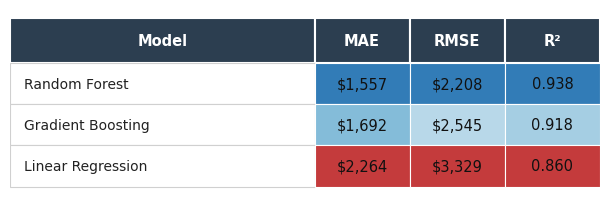

Saved: ../visualizations/results-manual.png


,Model,MAE,RMSE,R2
0,Random Forest,1556.759023,2208.292896,0.938228
1,Gradient Boosting,1692.261220,2544.790425,0.917968
2,Linear Regression,2263.637217,3329.342173,0.859590


In [3]:
manual = pd.read_csv("../data/manual-test-results.csv")
# Already sorted by R² descending? Sort to be safe (best first).
manual = manual.sort_values("R2", ascending=False).reset_index(drop=True)

render_results_table(
    manual,
    out_path="../visualizations/results-manual.png",
    title=None,
    row_height=0.48,
)
manual

### 4 - PyCaret Raw Top 15 (slide 6)

/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmaps[col])
/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmaps[col])
/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cma

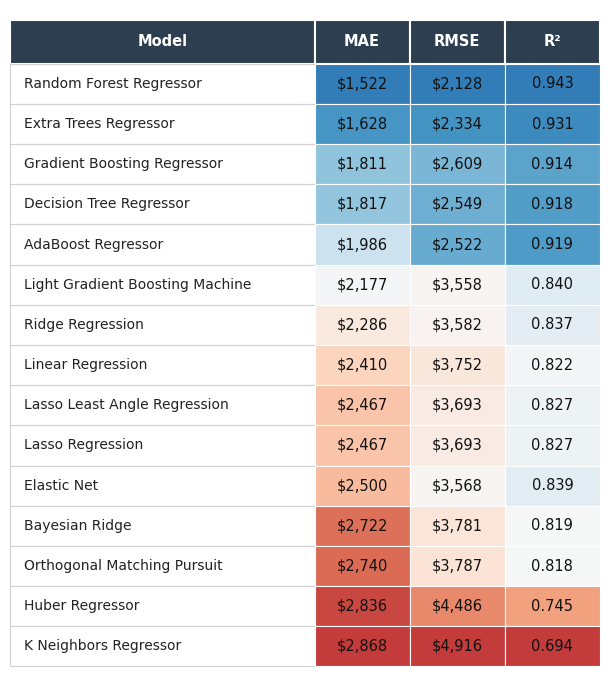

Saved: ../visualizations/results-pycaret-raw.png


,Model,MAE,RMSE,R2
0,Random Forest Regressor,1522,2128,0.9426
1,Extra Trees Regressor,1628,2334,0.9310
2,Gradient Boosting Regressor,1811,2609,0.9138
3,Decision Tree Regressor,1817,2549,0.9177
4,AdaBoost Regressor,1986,2522,0.9194
5,Light Gradient Boosting Machine,2177,3558,0.8397
6,Ridge Regression,2286,3582,0.8374
7,Linear Regression,2410,3752,0.8217
8,Lasso Least Angle Regression,2467,3693,0.8273
9,Lasso Regression,2467,3693,0.8273


In [4]:
pycaret_raw = pd.read_csv("../pycaret/pycaret-raw-test-results.csv")
pycaret_raw = pycaret_raw.sort_values("MAE").head(15).reset_index(drop=True)

render_results_table(
    pycaret_raw,
    out_path="../visualizations/results-pycaret-raw.png",
    title=None,
)
pycaret_raw

### 5 - PyCaret Preprocessed Top 15 (slide 7)

/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmaps[col])
/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmaps[col])
/var/folders/dn/v1s4f5b14_d8qt9wkt29wjdh0000gn/T/ipykernel_49315/3991949634.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cma

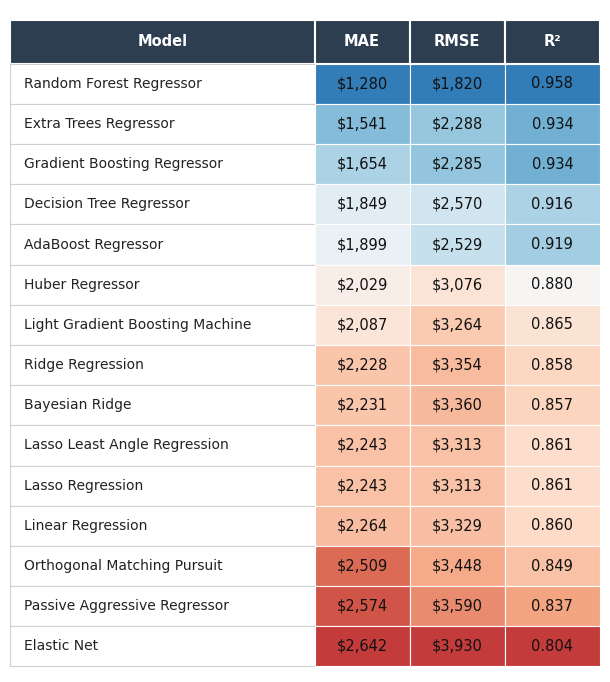

Saved: ../visualizations/results-pycaret-preprocessed.png


,Model,MAE,RMSE,R2
0,Random Forest Regressor,1280,1820,0.9580
1,Extra Trees Regressor,1541,2288,0.9337
2,Gradient Boosting Regressor,1654,2285,0.9339
3,Decision Tree Regressor,1849,2570,0.9163
4,AdaBoost Regressor,1899,2529,0.9190
5,Huber Regressor,2029,3076,0.8801
6,Light Gradient Boosting Machine,2087,3264,0.8650
7,Ridge Regression,2228,3354,0.8575
8,Bayesian Ridge,2231,3360,0.8570
9,Lasso Least Angle Regression,2243,3313,0.8610


In [5]:
pycaret_pre = pd.read_csv("../pycaret/pycaret-preprocessed-test-results.csv")
pycaret_pre = pycaret_pre.sort_values("MAE").head(15).reset_index(drop=True)

render_results_table(
    pycaret_pre,
    out_path="../visualizations/results-pycaret-preprocessed.png",
    title=None,
)
pycaret_pre

### 6 - Summary

All three tables share:
- Blue = good, red = bad — matches the `RdBu_r` palette used in the correlation heatmap (`03-eda.ipynb`).
- Same fonts, header styling, cell padding, and numeric formatting.
- Per-column normalisation so the colour gradient reflects relative performance within each metric.

When metrics shift (e.g. after a preprocessing change or PyCaret re-run), re-executing this notebook regenerates all three PNGs from the CSV sources of truth — no manual spreadsheet edits needed.